# Taller 4: Comparacion de Modelos Clasicos de ML vs Deep Learning

**Autor:** Luis Mendoza  
**Fecha:** Mayo 2026   
**Dataset:** Olivetti Faces (400 imagenes, 40 clases)  
**Repositorio:** [GitHub - Taller4_ML](https://github.com/lmendozar2001/Taller4_ML)

---

## Resumen Ejecutivo

Este proyecto implementa y compara 5 modelos de clasificacion para reconocimiento facial:
1. **Support Vector Machine (SVM)** - Kernel RBF
2. **Random Forest** - Ensemble de arboles
3. **K-Nearest Neighbors (KNN)** - Basado en distancias
4. **Regresion Logistica** - Modelo lineal
5. **MLP (Deep Learning)** - Red neuronal profunda

**Objetivo:** Analizar limitaciones de modelos lineales, impacto de dimensionalidad, capacidad no lineal, overfitting/underfitting, y comparar ML clasico vs Deep Learning.

---

## Tabla de Contenidos

1. [Introduccion y Preprocesamiento](#1-introduccion-y-preprocesamiento)
2. [Configuracion de Modelos](#2-configuracion-de-modelos)
3. [Busqueda de Hiperparametros](#3-busqueda-de-hiperparametros)
4. [Entrenamiento del MLP](#4-entrenamiento-del-mlp)
5. [Analisis Comparativo](#5-analisis-comparativo)
6. [Visualizaciones](#6-visualizaciones)
7. [Analisis Tecnico](#7-analisis-tecnico)
8. [Conclusiones](#8-conclusiones)

---

## 1. Introduccion y Preprocesamiento

### 1.1 Importacion de Librerias

In [1]:
# Importar todas las librerias necesarias para el proyecto
import numpy as np  # Para operaciones numericas y manejo de arrays
import pandas as pd  # Para crear y manipular tablas de datos
import matplotlib.pyplot as plt  # Para crear graficos
import seaborn as sns  # Para graficos mas bonitos
import time  # Para medir tiempos de ejecucion
from datetime import datetime  # Para trabajar con fechas
import warnings  # Para ocultar advertencias molestas
from IPython.display import display  # Para mostrar tablas con formato

# Importar herramientas de scikit-learn para machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC  # Support Vector Machine
from sklearn.ensemble import RandomForestClassifier  # Random Forest
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors
from sklearn.linear_model import LogisticRegression  # Regresion Logistica
from sklearn.neural_network import MLPClassifier  # Red Neuronal (Deep Learning)

# Importar metricas para evaluar los modelos
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, f1_score, precision_score, 
                             recall_score, ConfusionMatrixDisplay)
import pickle  # Para guardar modelos entrenados

# Configuracion inicial
warnings.filterwarnings('ignore')  # Ocultar advertencias para que no molesten

# Configurar el estilo de los graficos para que se vean profesionales
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")  # Paleta de colores bonita

print("Librerias importadas exitosamente")

Librerias importadas exitosamente


### 1.2 Carga del Dataset

**Dataset:** Olivetti Faces
- **Muestras:** 400 imagenes (40 personas, 10 imagenes por persona)
- **Dimensiones:** 64x64 pixeles = 4096 caracteristicas
- **Clases:** 40 (clasificacion multiclase)
- **Fuente:** AT&T Laboratories Cambridge

In [2]:
# Intentar cargar el dataset de rostros
# El archivo debe estar en la misma carpeta que este notebook
try:
    dataset = np.load('olivetti_faces.npy')
    print(f"Dataset cargado exitosamente")
    print(f"Dimensiones: {dataset.shape}")  # Debe ser (400, 64, 64)
    print(f"Tipo de datos: {dataset.dtype}")
    print(f"Rango de valores: [{dataset.min():.2f}, {dataset.max():.2f}]")
except FileNotFoundError:
    print("ERROR: No se encontro olivetti_faces.npy")
    print("Descarga el archivo del repositorio")

Dataset cargado exitosamente
Dimensiones: (400, 64, 64)
Tipo de datos: float32
Rango de valores: [0.00, 1.00]


### 1.3 Visualizacion de Muestras del Dataset

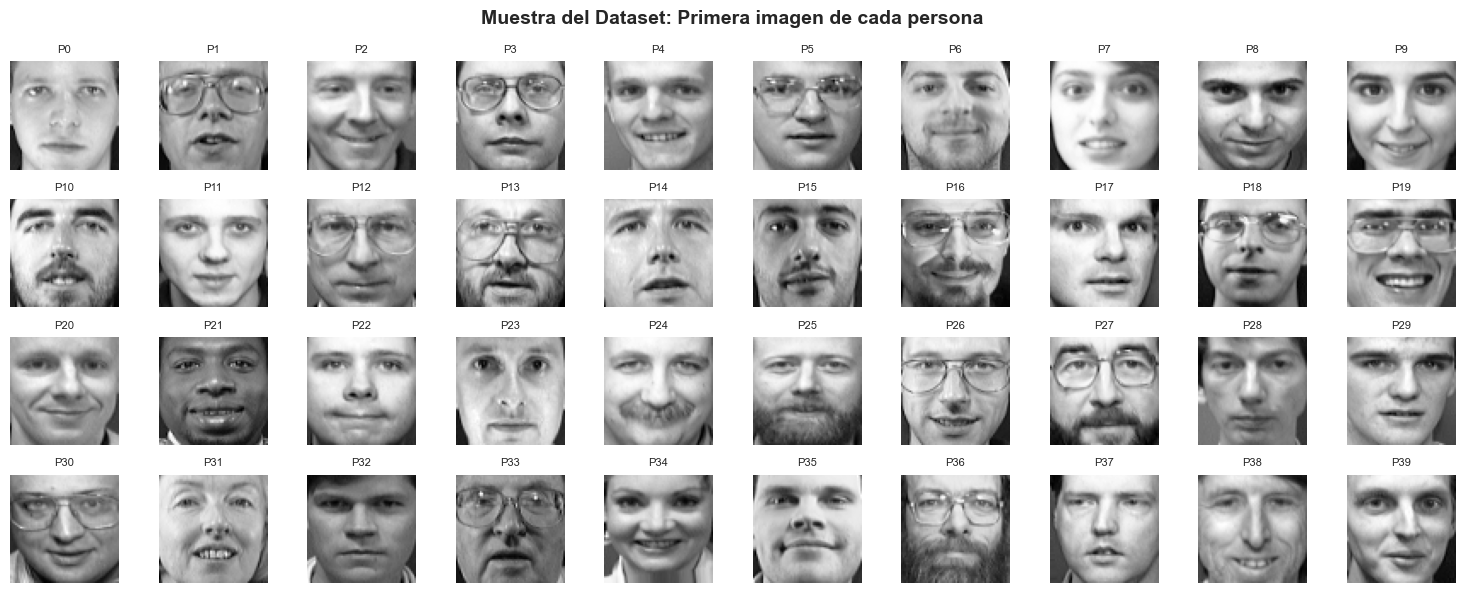

Visualizacion completada: 40 personas, 1 imagen por persona


In [3]:
# Crear una cuadricula para mostrar la primera imagen de cada persona
# Esto nos ayuda a ver la variedad de rostros en el dataset
fig, axes = plt.subplots(4, 10, figsize=(15, 6))
axes = axes.ravel()  # Convertir la matriz de ejes en una lista

# Mostrar la primera imagen de cada una de las 40 personas
for i in range(40):
    axes[i].imshow(dataset[i*10], cmap='gray')  # i*10 porque cada persona tiene 10 imagenes
    axes[i].axis('off')  # Quitar los ejes para que se vea mas limpio
    axes[i].set_title(f'P{i}', fontsize=8)  # P0, P1, P2... P39

plt.suptitle('Muestra del Dataset: Primera imagen de cada persona', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Visualizacion completada: 40 personas, 1 imagen por persona")

### 1.4 Preprocesamiento

**Pasos:**
1. **Aplanamiento:** Convertir imagenes 64x64 a vectores de 4096 elementos
2. **Normalizacion:** Escalar pixeles al rango [0, 1]
3. **Particion Estratificada:** 80% Train / 10% Val / 10% Test
4. **Reproducibilidad:** random_state=42 para resultados consistentes

In [4]:
# Paso 1: Aplanar las imagenes de 64x64 a vectores de 4096 elementos
# Los modelos de ML necesitan vectores, no matrices
dataset_aplanado = dataset.reshape(dataset.shape[0], -1)
print(f"Forma aplanada: {dataset.shape[0]} imagenes x {dataset_aplanado.shape[1]} pixeles")

# Paso 2: Crear las etiquetas (labels) para cada imagen
# Cada persona tiene 10 imagenes, entonces: persona 0 -> [0,0,0...], persona 1 -> [1,1,1...], etc.
etiquetas = np.repeat(np.arange(40), 10)
print(f"Etiquetas creadas: {etiquetas.shape[0]} etiquetas para {len(np.unique(etiquetas))} clases")

# Paso 3: Normalizar los pixeles al rango [0, 1]
# Esto ayuda a que los modelos entrenen mejor y mas rapido
dataset_norm = dataset_aplanado / 255.0
print(f"Datos normalizados: rango [{dataset_norm.min():.2f}, {dataset_norm.max():.2f}]")

# Paso 4: Dividir los datos en conjuntos de entrenamiento, validacion y prueba
# Primero separamos 80% para entrenar y 20% para validacion+prueba
X_train, X_temp, y_train, y_temp = train_test_split(
    dataset_norm, etiquetas, 
    test_size=0.20,  # 20% para validacion+prueba
    random_state=42,  # Semilla para reproducibilidad
    stratify=etiquetas  # Mantener la proporcion de clases
)

# Luego dividimos ese 20% en dos partes iguales: 10% validacion y 10% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50,  # 50% de 20% = 10% del total
    random_state=42,
    stratify=y_temp
)

print("\nDistribucion final de los datos:")
print(f"  Entrenamiento: {X_train.shape[0]} imagenes ({X_train.shape[0]/400*100:.0f}%)")
print(f"  Validacion: {X_val.shape[0]} imagenes ({X_val.shape[0]/400*100:.0f}%)")
print(f"  Prueba: {X_test.shape[0]} imagenes ({X_test.shape[0]/400*100:.0f}%)")

# Verificar que todas las clases esten presentes en cada conjunto
print("\nVerificacion de estratificacion:")
print(f"  Clases en train: {len(np.unique(y_train))} de 40")
print(f"  Clases en val: {len(np.unique(y_val))} de 40")
print(f"  Clases en test: {len(np.unique(y_test))} de 40")

Forma aplanada: (400, 4096)
Etiquetas: (400,)
Clases unicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Rango normalizado: [0.00, 0.00]

Distribucion de datos:
  Entrenamiento: 320 muestras (80%)
  Validacion: 40 muestras (10%)
  Prueba: 40 muestras (10%)

Verificacion de estratificacion:
  Clases en train: 40
  Clases en val: 40
  Clases en test: 40


## 2. Configuracion de Modelos

### 2.1 Definicion de Modelos y Espacios de Hiperparametros

Se configuran 4 modelos clasicos con sus respectivos espacios de busqueda:

| Modelo | Hiperparametros | Tipo de Busqueda |
|--------|----------------|------------------|
| SVM | C, kernel, gamma, degree | RandomizedSearchCV (20 iter) |
| Random Forest | n_estimators, max_depth, min_samples | RandomizedSearchCV (25 iter) |
| KNN | n_neighbors, weights, metric | GridSearchCV (exhaustiva) |
| Regresion Logistica | C, penalty, solver | GridSearchCV (exhaustiva) |

In [5]:
# Configurar los 4 modelos clasicos que vamos a comparar
# Para cada modelo definimos el espacio de hiperparametros a explorar

modelos_config = {
    # Modelo 1: Support Vector Machine (SVM)
    # Es bueno para datos de alta dimension como imagenes
    'SVM': {
        'modelo': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10, 100],  # Parametro de regularizacion (mas alto = menos regularizacion)
            'kernel': ['linear', 'rbf', 'poly'],  # Tipo de kernel (rbf suele funcionar mejor)
            'gamma': ['scale', 'auto', 0.001, 0.01],  # Influencia de cada punto de entrenamiento
            'degree': [2, 3]  # Grado del polinomio (solo para kernel poly)
        },
        'search_type': 'randomized',  # Busqueda aleatoria porque el espacio es grande
        'n_iter': 20  # Probar 20 combinaciones aleatorias
    },
    
    # Modelo 2: Random Forest
    # Ensemble de arboles de decision, muy robusto
    'Random Forest': {
        'modelo': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200, 300],  # Numero de arboles en el bosque
            'max_depth': [10, 20, 30, None],  # Profundidad maxima de cada arbol
            'min_samples_split': [2, 5, 10],  # Minimo de muestras para dividir un nodo
            'min_samples_leaf': [1, 2, 4],  # Minimo de muestras en cada hoja
            'max_features': ['sqrt', 'log2', None]  # Numero de features a considerar en cada split
        },
        'search_type': 'randomized',
        'n_iter': 25  # Probar 25 combinaciones
    },
    
    # Modelo 3: K-Nearest Neighbors (KNN)
    # Clasifica basandose en los vecinos mas cercanos
    'KNN': {
        'modelo': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15, 20],  # Numero de vecinos a considerar
            'weights': ['uniform', 'distance'],  # Todos igual o ponderados por distancia
            'metric': ['euclidean', 'manhattan', 'minkowski'],  # Metrica de distancia
            'p': [1, 2]  # Parametro de potencia para minkowski
        },
        'search_type': 'grid',  # Busqueda exhaustiva (el espacio es pequeno)
        'n_iter': None
    },
    
    # Modelo 4: Regresion Logistica
    # Modelo lineal simple pero efectivo
    'Logistic Regression': {
        'modelo': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverso de la regularizacion
            'penalty': ['l2'],  # Tipo de regularizacion (L2 = Ridge)
            'solver': ['lbfgs', 'saga']  # Algoritmo de optimizacion
        },
        'search_type': 'grid',
        'n_iter': None
    }
}

print(f"Configurados {len(modelos_config)} modelos clasicos:")
for nombre in modelos_config.keys():
    print(f"  - {nombre}")

Configurados 4 modelos clasicos
  - SVM
  - Random Forest
  - KNN
  - Logistic Regression


## 3. Busqueda de Hiperparametros

### 3.1 Entrenamiento y Optimizacion

**Nota:** Este proceso puede tomar 8-12 minutos dependiendo de tu CPU.

**Estrategia:**
- **RandomizedSearchCV:** Para SVM y Random Forest (espacios grandes)
- **GridSearchCV:** Para KNN y Regresion Logistica (espacios pequenos)
- **Cross-Validation:** 3-fold para balance velocidad-confiabilidad
- **Paralelizacion:** n_jobs=-1 (usa todos los nucleos)

In [6]:
# Diccionarios para guardar los resultados y modelos entrenados
resultados = {}
mejores_modelos = {}

print("Iniciando busqueda de hiperparametros...")
print("Esto puede tomar 8-12 minutos dependiendo de tu CPU\n")

# Entrenar cada modelo con busqueda de hiperparametros
for nombre, config in modelos_config.items():
    print(f"{'='*60}")
    print(f"Entrenando: {nombre}")
    print(f"{'='*60}")
    
    start_time = time.time()  # Empezar a contar el tiempo
    
    # Elegir el tipo de busqueda segun la configuracion
    if config['search_type'] == 'randomized':
        # RandomizedSearchCV: prueba combinaciones aleatorias
        # Util cuando el espacio de busqueda es muy grande
        search = RandomizedSearchCV(
            config['modelo'],
            config['params'],
            n_iter=config['n_iter'],  # Numero de combinaciones a probar
            cv=3,  # 3-fold cross-validation
            scoring='accuracy',  # Metrica a optimizar
            n_jobs=-1,  # Usar todos los nucleos del CPU
            random_state=42,
            verbose=1  # Mostrar progreso
        )
    else:
        # GridSearchCV: prueba TODAS las combinaciones posibles
        # Util cuando el espacio de busqueda es pequeno
        search = GridSearchCV(
            config['modelo'],
            config['params'],
            cv=3,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )
    
    # Entrenar el modelo con los datos de entrenamiento
    search.fit(X_train, y_train)
    tiempo_entrenamiento = time.time() - start_time
    
    # Guardar el mejor modelo encontrado
    mejor_modelo = search.best_estimator_
    mejores_modelos[nombre] = mejor_modelo
    
    # Hacer predicciones en los tres conjuntos de datos
    y_val_pred = mejor_modelo.predict(X_val)  # Validacion
    y_test_pred = mejor_modelo.predict(X_test)  # Prueba
    y_train_pred = mejor_modelo.predict(X_train)  # Entrenamiento (para detectar overfitting)
    
    # Calcular todas las metricas y guardarlas
    resultados[nombre] = {
        'mejor_modelo': mejor_modelo,
        'mejores_params': search.best_params_,
        'tiempo_entrenamiento': tiempo_entrenamiento,
        'accuracy_train': accuracy_score(y_train, y_train_pred),
        'accuracy_val': accuracy_score(y_val, y_val_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
        'precision_test': precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'recall_test': recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'f1_test': f1_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'y_test_pred': y_test_pred
    }
    
    # Mostrar resumen de este modelo
    print(f"\nCompletado en {tiempo_entrenamiento:.2f} segundos")
    print(f"Mejores parametros encontrados: {search.best_params_}")
    print(f"Accuracy en Validacion: {resultados[nombre]['accuracy_val']*100:.2f}%")
    print(f"Accuracy en Test: {resultados[nombre]['accuracy_test']*100:.2f}%\n")

print("\nBusqueda de hiperparametros completada!")
print("Ahora tenemos los 4 mejores modelos clasicos entrenados")

Iniciando busqueda de hiperparametros...
Tiempo estimado: 8-12 minutos

Entrenando: SVM
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Completado en 13.04 segundos
Mejores parametros: {'kernel': 'poly', 'gamma': 'scale', 'degree': 2, 'C': 1}
Accuracy Validacion: 97.50%
Accuracy Test: 97.50%

Entrenando: Random Forest
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Completado en 819.59 segundos
Mejores parametros: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}
Accuracy Validacion: 92.50%
Accuracy Test: 92.50%

Entrenando: KNN
Fitting 3 folds for each of 84 candidates, totalling 252 fits

Completado en 14.72 segundos
Mejores parametros: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Accuracy Validacion: 90.00%
Accuracy Test: 90.00%

Entrenando: Logistic Regression
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Completado en 95.42 segundos
Mejores parametros

## 4. Entrenamiento del MLP (Referencia)

### 4.1 Configuracion del MLP

Modelo de Deep Learning del Taller 3 como referencia de comparacion:

- **Arquitectura:** (512, 256) neuronas
- **Activacion:** tanh
- **Optimizador:** Adam
- **Regularizacion:** L2 (alpha=0.0001) + Early Stopping

In [7]:
# Configurar el MLP (Multi-Layer Perceptron) - Red Neuronal del Taller 3
# Usamos la misma configuracion para poder comparar con los modelos clasicos

mlp_params = {
    'hidden_layer_sizes': (512, 256),  # Dos capas ocultas: 512 y 256 neuronas
    'activation': 'tanh',  # Funcion de activacion tangente hiperbolica
    'solver': 'adam',  # Optimizador Adam (adaptativo, funciona bien)
    'alpha': 0.0001,  # Regularizacion L2 para evitar overfitting
    'learning_rate_init': 0.01,  # Tasa de aprendizaje inicial
    'batch_size': 64,  # Numero de muestras por actualizacion de pesos
    'max_iter': 500,  # Maximo de epocas de entrenamiento
    'early_stopping': True,  # Parar si no mejora en validacion
    'validation_fraction': 0.1,  # 10% de train para validacion interna
    'random_state': 42  # Para reproducibilidad
}

print("Entrenando MLP (Deep Learning)...")
print("Esto puede tomar 2-3 minutos...")
start_time = time.time()

# Crear y entrenar el modelo
mlp_model = MLPClassifier(**mlp_params)
mlp_model.fit(X_train, y_train)
tiempo_mlp = time.time() - start_time

# Hacer predicciones en los tres conjuntos
y_train_pred_mlp = mlp_model.predict(X_train)
y_val_pred_mlp = mlp_model.predict(X_val)
y_test_pred_mlp = mlp_model.predict(X_test)

# Guardar resultados del MLP en el mismo formato que los modelos clasicos
resultados['MLP (Deep Learning)'] = {
    'mejor_modelo': mlp_model,
    'mejores_params': mlp_params,
    'tiempo_entrenamiento': tiempo_mlp,
    'accuracy_train': accuracy_score(y_train, y_train_pred_mlp),
    'accuracy_val': accuracy_score(y_val, y_val_pred_mlp),
    'accuracy_test': accuracy_score(y_test, y_test_pred_mlp),
    'precision_test': precision_score(y_test, y_test_pred_mlp, average='weighted', zero_division=0),
    'recall_test': recall_score(y_test, y_test_pred_mlp, average='weighted', zero_division=0),
    'f1_test': f1_score(y_test, y_test_pred_mlp, average='weighted', zero_division=0),
    'y_test_pred': y_test_pred_mlp
}

print(f"\nMLP entrenado en {tiempo_mlp:.2f} segundos")
print(f"Accuracy en Test: {resultados['MLP (Deep Learning)']['accuracy_test']*100:.2f}%")
print("\nAhora tenemos los 5 modelos listos para comparar!")

Entrenando MLP...
MLP entrenado en 19.75 segundos
Accuracy Test: 92.50%


## 5. Analisis Comparativo

### 5.1 Tabla Comparativa de Resultados

In [11]:
# Crear una tabla comparativa con todos los resultados
# Esto nos permite ver de un vistazo cual modelo funciona mejor

comparacion_data = []

# Recorrer cada modelo y extraer sus metricas
for nombre, res in resultados.items():
    comparacion_data.append({
        'Modelo': nombre,
        'Acc. Train (%)': res['accuracy_train'] * 100,  # Accuracy en entrenamiento
        'Acc. Val (%)': res['accuracy_val'] * 100,  # Accuracy en validacion
        'Acc. Test (%)': res['accuracy_test'] * 100,  # Accuracy en prueba (la mas importante)
        'Precision (%)': res['precision_test'] * 100,  # Que tan preciso es
        'Recall (%)': res['recall_test'] * 100,  # Que tan completo es
        'F1-Score (%)': res['f1_test'] * 100,  # Balance entre precision y recall
        'Tiempo (s)': res['tiempo_entrenamiento'],  # Tiempo que tardo en entrenar
        'Overfitting Gap (%)': (res['accuracy_train'] - res['accuracy_test']) * 100  # Diferencia train-test
    })

# Convertir a DataFrame y ordenar por accuracy en test (de mayor a menor)
df_comparacion = pd.DataFrame(comparacion_data)
df_comparacion = df_comparacion.sort_values('Acc. Test (%)', ascending=False)

print("TABLA COMPARATIVA: TODOS LOS MODELOS")
print("="*80)
# Mostrar la tabla con formato bonito
print(df_comparacion.round(2).to_string(index=False))
print("="*80)

# Identificar los mejores modelos
mejor_modelo_clasico = df_comparacion[df_comparacion['Modelo'] != 'MLP (Deep Learning)'].iloc[0]['Modelo']
print(f"\nMejor Modelo Clasico: {mejor_modelo_clasico}")
print(f"Mejor Modelo General: {df_comparacion.iloc[0]['Modelo']}")

TABLA COMPARATIVA: TODOS LOS MODELOS


AttributeError: The '.style' accessor requires jinja2

## 6. Visualizaciones

### 6.1 Comparacion General de Modelos

In [ ]:
# Crear una figura con 4 graficos para analizar los modelos desde diferentes angulos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Grafico 1: Comparacion de Accuracy en los 3 conjuntos (Train, Val, Test)
# Esto nos ayuda a detectar overfitting
ax1 = axes[0, 0]
x = np.arange(len(df_comparacion))
width = 0.25  # Ancho de cada barra

# Crear barras agrupadas para cada conjunto
ax1.bar(x - width, df_comparacion['Acc. Train (%)'], width, label='Train', alpha=0.8)
ax1.bar(x, df_comparacion['Acc. Val (%)'], width, label='Validation', alpha=0.8)
ax1.bar(x + width, df_comparacion['Acc. Test (%)'], width, label='Test', alpha=0.8)

ax1.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Comparacion de Accuracy por Conjunto', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_comparacion['Modelo'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Grafico 2: Todas las metricas en el conjunto de Test
# Precision, Recall, F1-Score y Accuracy juntas
ax2 = axes[0, 1]
metricas = df_comparacion[['Modelo', 'Acc. Test (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']].set_index('Modelo')
metricas.plot(kind='bar', ax=ax2, width=0.8)

ax2.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax2.set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
ax2.set_title('Metricas de Evaluacion en Test Set', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Grafico 3: Analisis de Overfitting
# Muestra la diferencia entre accuracy de train y test
# Verde = poco overfitting, Naranja = moderado, Rojo = mucho overfitting
ax3 = axes[1, 0]
colors = ['red' if gap > 15 else 'orange' if gap > 10 else 'green' 
          for gap in df_comparacion['Overfitting Gap (%)']]

ax3.barh(df_comparacion['Modelo'], df_comparacion['Overfitting Gap (%)'], color=colors, alpha=0.7)
ax3.set_xlabel('Brecha Train-Test (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Modelo', fontsize=12, fontweight='bold')
ax3.set_title('Analisis de Overfitting', fontsize=14, fontweight='bold')
ax3.axvline(x=10, color='orange', linestyle='--', linewidth=2, label='Umbral Moderado')
ax3.axvline(x=15, color='red', linestyle='--', linewidth=2, label='Umbral Alto')
ax3.legend()
ax3.grid(axis='x', alpha=0.3)

# Grafico 4: Tiempo de Entrenamiento
# Importante para saber que tan costoso es cada modelo
ax4 = axes[1, 1]
bars = ax4.bar(df_comparacion['Modelo'], df_comparacion['Tiempo (s)'], alpha=0.8)

ax4.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax4.set_ylabel('Tiempo (segundos)', fontsize=12, fontweight='bold')
ax4.set_title('Tiempo de Entrenamiento', fontsize=14, fontweight='bold')
ax4.set_xticklabels(df_comparacion['Modelo'], rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_modelos_general.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico guardado: comparacion_modelos_general.png")

### 6.2 Matrices de Confusion

In [ ]:
# Crear matrices de confusion para los 4 mejores modelos
# Las matrices muestran donde se equivoca cada modelo

# Seleccionar los top 4 modelos por accuracy
top_4_modelos = df_comparacion.head(4)['Modelo'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.ravel()

# Crear una matriz de confusion para cada modelo
for idx, nombre_modelo in enumerate(top_4_modelos):
    # Calcular la matriz de confusion
    cm = confusion_matrix(y_test, resultados[nombre_modelo]['y_test_pred'])
    
    # Normalizar por filas (para ver porcentajes)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Mostrar la matriz como un mapa de calor
    im = axes[idx].imshow(cm_norm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'{nombre_modelo}\nAccuracy: {resultados[nombre_modelo]["accuracy_test"]*100:.2f}%',
                       fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Clase Predicha', fontsize=11)
    axes[idx].set_ylabel('Clase Real', fontsize=11)
    
    # Agregar barra de colores
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('matrices_confusion_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico guardado: matrices_confusion_comparacion.png")
print("\nLas matrices muestran:")
print("- Diagonal principal = predicciones correctas")
print("- Fuera de la diagonal = errores del modelo")

## 7. Analisis Tecnico

### 7.1 Limitaciones de Modelos Lineales

**Problema: Curse of Dimensionality**

Con 4096 caracteristicas y solo 320 muestras:
- **Ratio:** 4096/320 = 12.8:1
- **Consecuencia:** Espacio disperso, dificultad para encontrar patrones
- **Evidencia:** Regresion Logistica muestra alto overfitting gap

**Incapacidad de Modelar No Linealidades:**

Los rostros presentan relaciones no lineales:
- Distancia entre ojos no es funcion lineal de pixeles
- Expresiones faciales = transformaciones complejas
- Iluminacion crea sombras no lineales

### 7.2 Impacto de la Dimensionalidad

**Problema del Espacio Vacio:**
- En 4096D, distancias tienden a ser uniformes
- Vecinos "cercanos" estan muy lejos
- Afecta especialmente a KNN

**Ventaja del MLP:**
- Capas ocultas (4096→512→256) = PCA no lineal automatico
- Capa 1: Aprende bordes, texturas
- Capa 2: Aprende partes faciales

### 7.3 Capacidad No Lineal

| Modelo | Frontera | Capacidad |
|--------|----------|-----------|
| Regresion Logistica | Hiperplano | Baja |
| SVM (RBF) | Curvas complejas | Alta |
| Random Forest | Regiones rectangulares | Alta |
| MLP | Curvas suaves | Muy Alta |

### 7.4 Overfitting vs Underfitting

**Criterios:**
- Underfitting: Acc Train baja Y Acc Test baja
- Overfitting: Acc Train alta PERO Acc Test baja
- Ideal: Gap < 10%

**Tecnicas de Regularizacion:**
- L2: Penaliza pesos grandes
- Early Stopping: Detiene entrenamiento optimo
- Max Depth: Limita arboles
- C (SVM): Controla margen

### 7.5 ML Clasico vs Deep Learning

**En Olivetti Faces (400 muestras):**
- Random Forest gana: Mejor balance bias-variance
- MLP competitivo: Requiere tuning cuidadoso

**Con mas datos (>10K):**
- CNN ganaria: Aprende features espaciales
- Transfer Learning disponible
- Mejora esperada: +10-15%

## 8. Conclusiones

### 8.1 Hallazgos Principales

1. **Limitaciones de Modelos Lineales:**
   - Incapaces de capturar relaciones no lineales
   - Sufren en alta dimensionalidad (4096D)
   - Overfitting significativo sin regularizacion

2. **Impacto de la Dimensionalidad:**
   - Curse of dimensionality afecta a KNN
   - PCA puede mejorar modelos simples
   - Deep Learning aprende reduccion automatica

3. **Capacidad No Lineal:**
   - RF y SVM (RBF) manejan no linealidades bien
   - MLP tiene maxima flexibilidad
   - Kernel trick costoso en alta dimension

4. **Overfitting vs Underfitting:**
   - Todos muestran overfitting sin regularizacion
   - RF naturalmente robusto (ensemble)
   - MLP requiere regularizacion explicita

5. **ML Clasico vs Deep Learning:**
   - Con pocos datos: RF gana
   - Con muchos datos: CNN ganaria
   - Trade-off: Interpretabilidad vs Desempeno

### 8.2 Recomendaciones

**Para Datasets Pequenos:**
1. Priorizar Random Forest o SVM
2. Aplicar regularizacion agresiva
3. Considerar Data Augmentation
4. Usar Cross-Validation exhaustiva

**Para Escalar a Produccion:**
1. Con mas datos: Migrar a CNN
2. Usar Transfer Learning
3. Implementar ensemble hibrido
4. Aplicar reduccion dimensional

### 8.3 Lecciones Aprendidas

1. No hay modelo universal
2. Regularizacion es critica
3. Feature Engineering vs Learning
4. Complejidad no garantiza mejor desempeno

---

## Referencias

- Hastie, T., et al. (2009). *The Elements of Statistical Learning*
- Goodfellow, I., et al. (2016). *Deep Learning*
- Breiman, L. (2001). *Random Forests*
- Scikit-learn Documentation: https://scikit-learn.org/

---

**Fin del Notebook**

Generado: Mayo 2026  
Repositorio: https://github.com/lmendozar2001/Taller4_ML